In [4]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [5]:
df = pd.read_csv(
    "../data/processed/cases.csv"
)

print(df.shape)

df.head()

(40, 11)


,case_id,nomor_perkara,pengadilan,penggugat,tergugat,objek_sengketa,luas_tanah,ringkasan_fakta,amar_putusan,label,text_full
0,1,101/Pdt.G/2020/PN,PN Pasir Pengaraian yang memeriksa dan memutus...,AMarmo Rejo,l m b Mukahar,SHM No.01439/Kota,7.5,"Menimbang, bahwa Penggugat dengan surat gugat...",n n 1. Menyatakan Tergugat telah dipanggil sec...,Dikabulkan Sebagian,a i s e n o d n I k i l b u p e a R i s g e n ...
1,2,109/Pdt.G/2020/PN,PN Pasir Pengaraian yang memeriksa dan memutus...,ARiyanto,l m b Dangan,SHM No.00769/Kota,7.5,"Menimbang, bahwa Penggugat dengan surat gugat...",NaN,Lainnya,a i s e n o d n I k i l b u p e a R i s g e n ...
2,3,115/Pdt.G/2020/PN,PN Pasir Pengaraian yang memeriksa dan memutus...,AM. NANDAR,l m b JAMALUDIN,SHM No.01231/Kota,7.5,"Menimbang, bahwa Penggugat dengan surat gugat...",n n 1. Menyatakan Tergugat telah dipanggil sec...,Dikabulkan Sebagian,a i s e n o d n I k i l b u p e a R i s g e n ...
3,4,143/Pdt.G/2020/PN,PN Pasir Pengaraian yang memeriksa dan memutus...,I WAHYUNI,u a PAIMIN,SHM No.01249/Kota,10.0,"n A Menimbang, bahwa Penggugat dengan surat g...",n n 1. Menyatakan Tergugat telah dipanggil sec...,Dikabulkan Sebagian,a i s e n o d n I k i l b u p e a R i s g e n ...
4,5,148/Pdt.G/2020/PN,PN Pasir Pengaraian yang memeriksa dan memutus...,d g Sujadi,h Darman,SHM No.765/Kota,10.0,NaN,k a 1. Menyatakan Tergugat telah dipanggil sec...,Dikabulkan Sebagian,a i s e n o d n I k i l b u p e a R i s g e n ...


In [6]:
print(df.isnull().sum())

case_id            0
nomor_perkara      0
pengadilan         0
penggugat          0
tergugat           0
objek_sengketa     0
luas_tanah         0
ringkasan_fakta    5
amar_putusan       5
label              0
text_full          0
dtype: int64


In [4]:
print(
    df["label"].value_counts()
)

label
Dikabulkan Sebagian    33
Lainnya                 5
Dikabulkan              2
Name: count, dtype: int64


In [5]:
df["ringkasan_fakta"] = df["ringkasan_fakta"].fillna("")

# Hilangkan spasi ekstra di awal/akhir teks
df["ringkasan_fakta"] = df["ringkasan_fakta"].astype(str).str.strip()

vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(
    df["ringkasan_fakta"]
)

y = df["label"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
model = LinearSVC()

model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [8]:
import joblib

joblib.dump(model, "../models/svm_model.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [9]:
y_pred = model.predict(
    X_test
)

In [10]:
hasil = pd.DataFrame({
    "Actual": y_test,
    "Prediction": y_pred
})

hasil.head()

,Actual,Prediction
11,Dikabulkan Sebagian,Dikabulkan Sebagian
16,Lainnya,Dikabulkan Sebagian
24,Dikabulkan Sebagian,Dikabulkan Sebagian
8,Dikabulkan Sebagian,Dikabulkan Sebagian
7,Dikabulkan Sebagian,Dikabulkan Sebagian


In [11]:
hasil.to_csv(
    "../data/results/predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

In [12]:
acc = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy : {acc:.4f}"
)

Accuracy : 0.8750


In [13]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

                     precision    recall  f1-score   support

Dikabulkan Sebagian       0.88      1.00      0.93         7
            Lainnya       0.00      0.00      0.00         1

           accuracy                           0.88         8
          macro avg       0.44      0.50      0.47         8
       weighted avg       0.77      0.88      0.82         8



c:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [14]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[7 0]
 [1 0]]


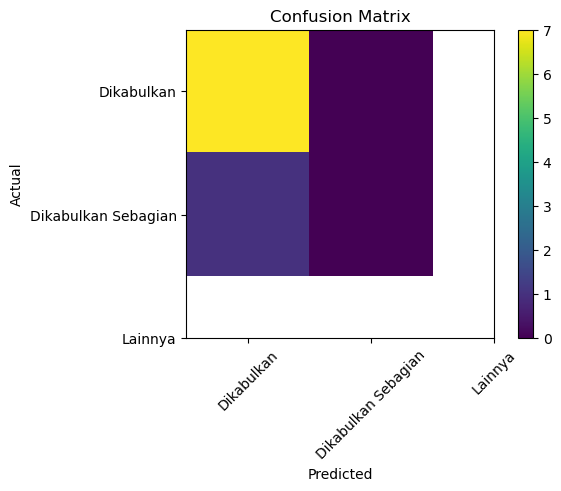

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(len(model.classes_)),
    model.classes_,
    rotation=45
)

plt.yticks(
    range(len(model.classes_)),
    model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [16]:
evaluation = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value":[
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred,average="weighted"),
        recall_score(y_test,y_pred,average="weighted"),
        f1_score(y_test,y_pred,average="weighted")
    ]
})

evaluation

c:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Metric,Value
0,Accuracy,0.875000
1,Precision,0.765625
2,Recall,0.875000
3,F1 Score,0.816667


In [17]:
evaluation.to_csv(
    "../data/results/evaluation.csv",
    index=False
)

In [2]:
print(df.isnull().sum())

NameError: name 'df' is not defined

In [19]:
print(df.columns.tolist())

['case_id', 'nomor_perkara', 'pengadilan', 'penggugat', 'tergugat', 'objek_sengketa', 'luas_tanah', 'ringkasan_fakta', 'amar_putusan', 'label', 'text_full']
